# Local-Value First-5 Statistics

This notebook computes and visualizes the three local-search value statistics discussed for eps-greedy first-5 runs:

1. $\Delta_{t,k} = L_{t,k}^{\text{so-far}} - G_t$
2. $\delta_{t,k} = L_{t,k}^{\text{so-far}} - L_{t,k-1}^{\text{so-far}}$
3. $z_{t,k} = \Delta_{t,k} / \mathrm{SD}_{\text{bias},t}$

where:
- $L_{t,k}^{\text{so-far}}$ is best local Tweedie-estimated score up to local iteration $k$ at timestep $t$
- $G_t$ is a global baseline at timestep $t$ (average-global or best-global; configurable)
- $\mathrm{SD}_{\text{bias},t}$ is timestep-wise SD of Tweedie bias, i.e. score_hat - final_score.

Data source: `../data/adap_eps_greedy/profiles/<MODEL>/<REWARD>/local_value_curve_from_first5_*.csv`


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 1.2,
})


In [2]:
# -----------------------------
# Config
# -----------------------------
PROFILE_ROOT = Path('../data/adap_eps_greedy/profiles')
MODEL = 'SD'  # 'SD' or 'EDM'

# Reward folder names under model directory.
REWARDS_BY_MODEL = {
    'SD': ['BRIGHTNESS', 'COMPRESSIBILITY', 'CLIP'],
    'EDM': ['BRIGHTNESS', 'COMPRESSIBILITY', 'CLASSIFIER'],
}

REWARDS = REWARDS_BY_MODEL[MODEL]

# Global baseline used in Delta and z definitions.
# 'avg_global'  -> Delta = best_local_so_far - avg_global_t
# 'best_global' -> Delta = best_local_so_far - best_global_t
BASELINE = 'avg_global'

# Optional filter to force a specific run signature substring in filename.
# Example: 'seed0_N4_K20_eps0.4_lam0.15'
RUN_TAG_CONTAINS = 'seed0_N4_K20_eps0.4_lam0.15'

PROFILE_ROOT


PosixPath('../data/adap_eps_greedy/profiles')

In [3]:
# -----------------------------
# Load helpers
# -----------------------------
def _latest_file(files):
    files = sorted(files, key=lambda p: p.stat().st_mtime)
    return files[-1] if files else None


def _find_profile_files(model, reward, kind_prefix, run_tag_contains=None):
    d = PROFILE_ROOT / model / reward
    if not d.exists():
        return []
    files = list(d.glob(f'{kind_prefix}*.csv'))
    if run_tag_contains:
        files = [p for p in files if run_tag_contains in p.name]
    return files


def load_local_value_curve(model, reward, run_tag_contains=None):
    files = _find_profile_files(
        model=model,
        reward=reward,
        kind_prefix='local_value_curve_from_first5_',
        run_tag_contains=run_tag_contains,
    )
    fp = _latest_file(files)
    if fp is None:
        return None, None
    df = pd.read_csv(fp)
    df['model'] = model
    df['reward'] = reward
    return df, fp


def load_z_curve(model, reward, run_tag_contains=None):
    files = _find_profile_files(
        model=model,
        reward=reward,
        kind_prefix='z_profile_from_first5_',
        run_tag_contains=run_tag_contains,
    )
    fp = _latest_file(files)
    if fp is None:
        return None, None
    df = pd.read_csv(fp)
    df['model'] = model
    df['reward'] = reward
    return df, fp


def compute_three_stats(curve_df, baseline='avg_global'):
    out = curve_df.copy()

    if baseline == 'avg_global':
        out['Delta_mean'] = out['gain_vs_avg_global_mean']
        out['Delta_se'] = out.get('gain_vs_avg_global_se', np.nan)
        out['z_mean'] = out['z_gain_vs_avg_global_mean']
        out['z_se'] = out.get('z_gain_vs_avg_global_se', np.nan)
    elif baseline == 'best_global':
        out['Delta_mean'] = out['gain_vs_best_global_mean']
        out['Delta_se'] = out.get('gain_vs_best_global_se', np.nan)
        out['z_mean'] = out['z_gain_vs_best_global_mean']
        out['z_se'] = out.get('z_gain_vs_best_global_se', np.nan)
    else:
        raise ValueError("baseline must be 'avg_global' or 'best_global'")

    out['delta_mean'] = out['marginal_gain_mean']
    out['delta_se'] = out.get('marginal_gain_se', np.nan)

    return out


In [4]:
# -----------------------------
# Load all selected rewards
# -----------------------------
curve_map = {}
zcurve_map = {}
source_rows = []

for reward in REWARDS:
    curve, cpath = load_local_value_curve(MODEL, reward, RUN_TAG_CONTAINS)
    zcurve, zpath = load_z_curve(MODEL, reward, RUN_TAG_CONTAINS)

    if curve is not None:
        curve = compute_three_stats(curve, baseline=BASELINE)
        curve_map[reward] = curve

    if zcurve is not None:
        zcurve_map[reward] = zcurve

    source_rows.append({
        'reward': reward,
        'curve_file': None if cpath is None else str(cpath),
        'z_curve_file': None if zpath is None else str(zpath),
        'curve_loaded': curve is not None,
        'z_curve_loaded': zcurve is not None,
    })

sources = pd.DataFrame(source_rows)
sources


,reward,curve_file,z_curve_file,curve_loaded,z_curve_loaded
0,BRIGHTNESS,../data/adap_eps_greedy/profiles/SD/BRIGHTNESS...,../data/adap_eps_greedy/profiles/SD/BRIGHTNESS...,True,True
1,COMPRESSIBILITY,../data/adap_eps_greedy/profiles/SD/COMPRESSIB...,../data/adap_eps_greedy/profiles/SD/COMPRESSIB...,True,True
2,CLIP,../data/adap_eps_greedy/profiles/SD/CLIP/local...,../data/adap_eps_greedy/profiles/SD/CLIP/z_pro...,True,True


## Statistic Definitions in Code

Given a row `(timestep_idx=t, local_iter_idx=k)` from `local_value_curve`:

- `Delta_mean` is:
  - `gain_vs_avg_global_mean` when `BASELINE='avg_global'`
  - `gain_vs_best_global_mean` when `BASELINE='best_global'`
- `delta_mean` is `marginal_gain_mean`
- `z_mean` is:
  - `z_gain_vs_avg_global_mean` when `BASELINE='avg_global'`
  - `z_gain_vs_best_global_mean` when `BASELINE='best_global'`

So the notebook's three plotted statistics are exactly $\Delta_{t,k}$, $\delta_{t,k}$, and $z_{t,k}$ (aggregated over complete units).


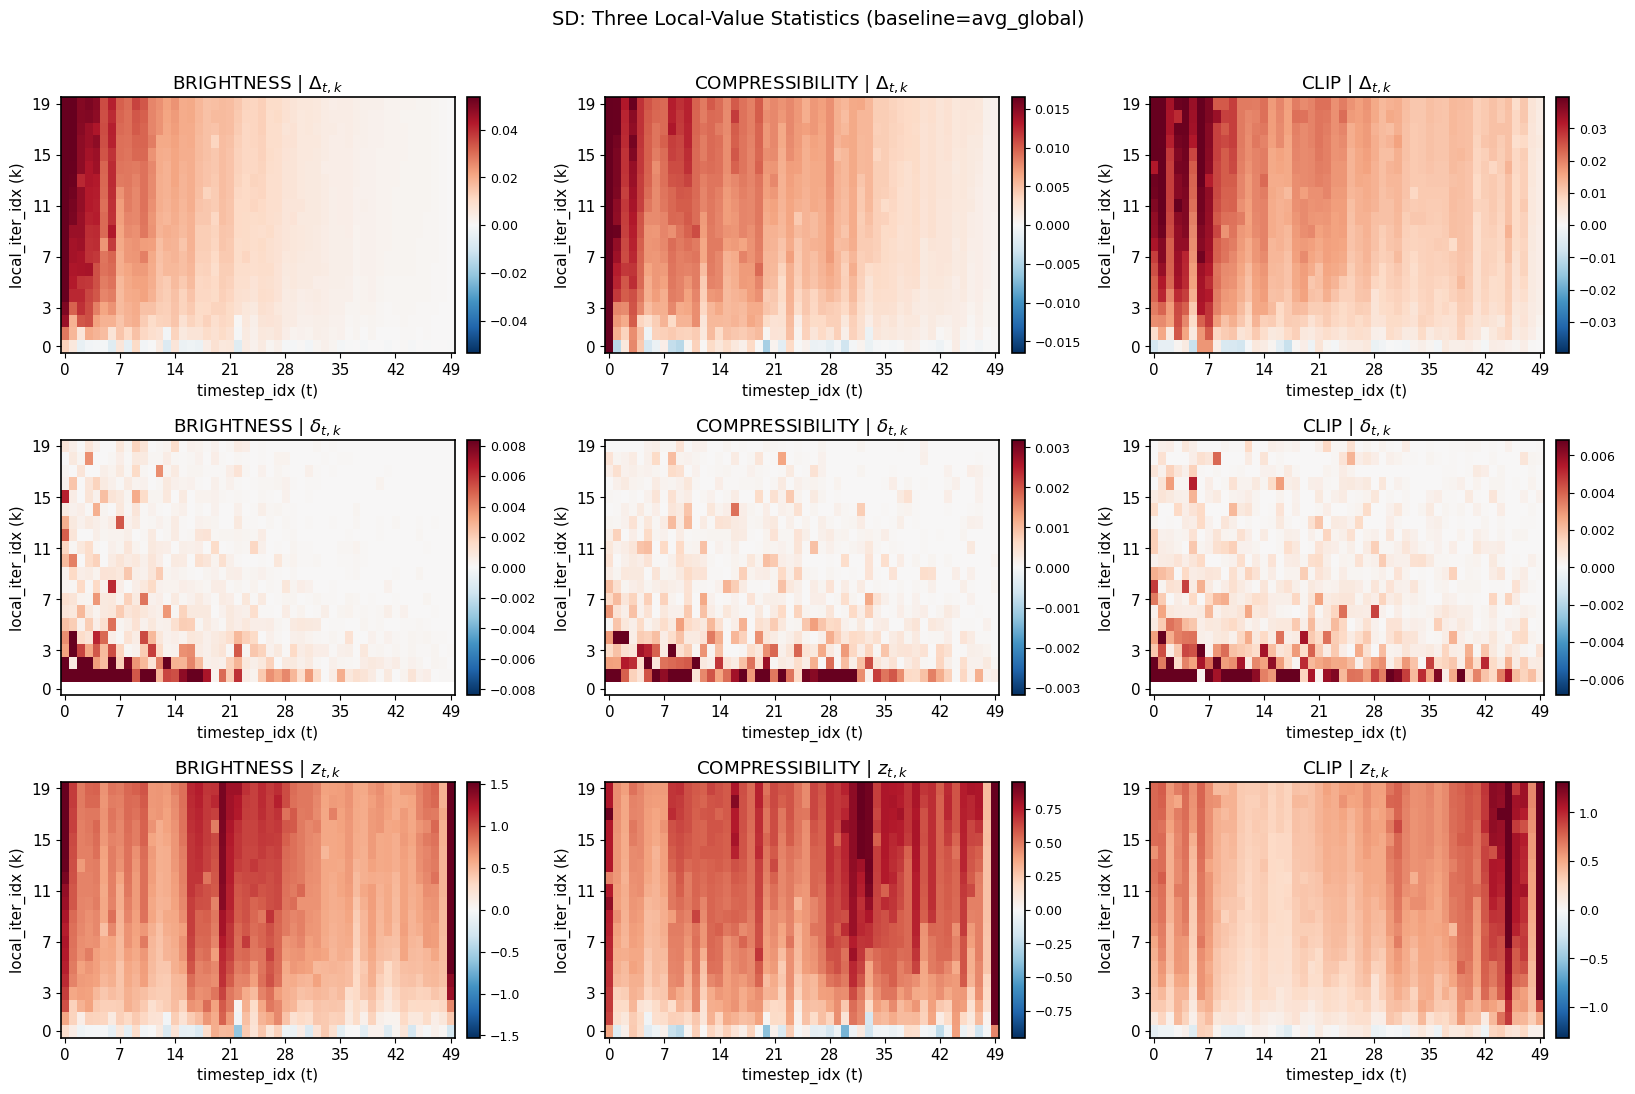

In [5]:
# -----------------------------
# 3 x R heatmaps: (Delta, delta, z) by reward
# x-axis: timestep t, y-axis: local iteration k
# -----------------------------
def _pivot_for_heatmap(df, value_col):
    p = df.pivot(index='local_iter_idx', columns='timestep_idx', values=value_col)
    p = p.sort_index().sort_index(axis=1)
    return p


def _sym_vlim(values, q=0.98):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (-1.0, 1.0)
    v = np.nanquantile(np.abs(vals), q)
    if not np.isfinite(v) or v <= 0:
        v = np.nanmax(np.abs(vals))
    if not np.isfinite(v) or v <= 0:
        v = 1.0
    return (-v, v)


stat_cols = [
    ('Delta_mean', r'$\Delta_{t,k}$'),
    ('delta_mean', r'$\delta_{t,k}$'),
    ('z_mean', r'$z_{t,k}$'),
]

loaded_rewards = [r for r in REWARDS if r in curve_map]
if len(loaded_rewards) == 0:
    raise RuntimeError('No local_value_curve files loaded. Check PROFILE_ROOT / MODEL / RUN_TAG_CONTAINS.')

fig, axes = plt.subplots(len(stat_cols), len(loaded_rewards), figsize=(5.5 * len(loaded_rewards), 3.6 * len(stat_cols)), squeeze=False)

for ri, reward in enumerate(loaded_rewards):
    df = curve_map[reward]
    for si, (col, label) in enumerate(stat_cols):
        ax = axes[si, ri]
        piv = _pivot_for_heatmap(df, col)

        vmin, vmax = _sym_vlim(piv.values)
        im = ax.imshow(
            piv.values,
            aspect='auto',
            origin='lower',
            interpolation='nearest',
            cmap='RdBu_r',
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(f'{reward} | {label}')
        ax.set_xlabel('timestep_idx (t)')
        ax.set_ylabel('local_iter_idx (k)')

        # Sparse ticks for readability.
        n_t = piv.shape[1]
        n_k = piv.shape[0]
        xt = np.linspace(0, max(0, n_t - 1), min(8, n_t)).astype(int)
        yt = np.linspace(0, max(0, n_k - 1), min(6, n_k)).astype(int)
        ax.set_xticks(xt)
        ax.set_xticklabels([str(piv.columns[i]) for i in xt])
        ax.set_yticks(yt)
        ax.set_yticklabels([str(piv.index[i]) for i in yt])

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cbar.ax.tick_params(labelsize=9)

fig.suptitle(f'{MODEL}: Three Local-Value Statistics (baseline={BASELINE})', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


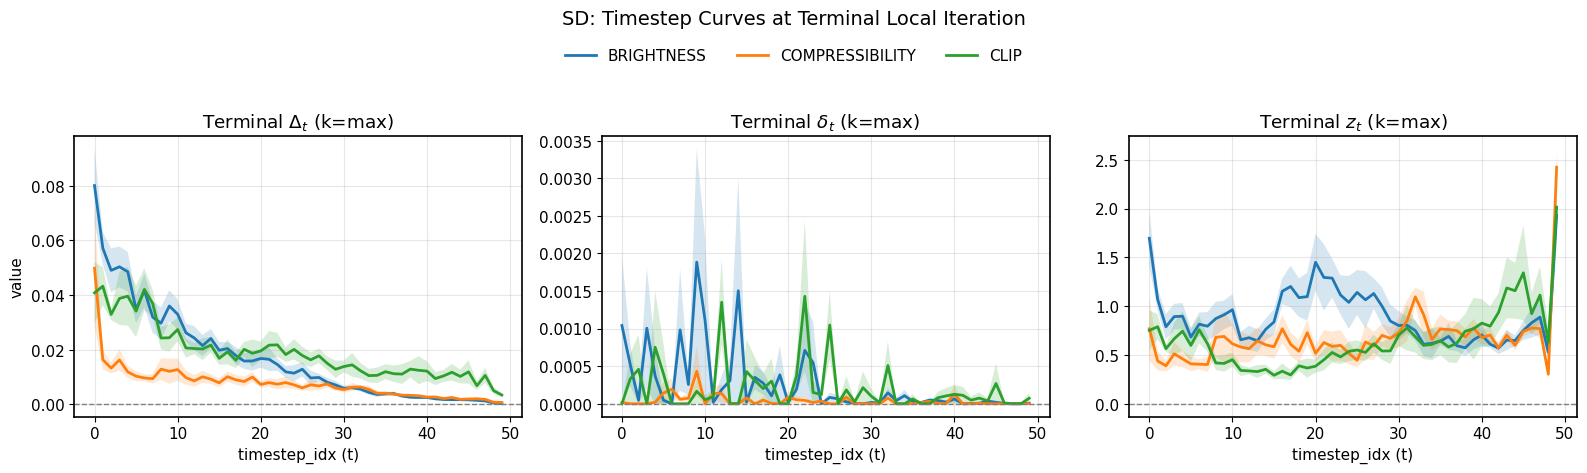

In [6]:
# -----------------------------
# Policy-focused curves vs timestep t
# Using k = max local_iter_idx at each t
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=False)

for reward in loaded_rewards:
    df = curve_map[reward].copy()
    kmax_df = df.loc[df.groupby('timestep_idx')['local_iter_idx'].idxmax()].sort_values('timestep_idx')

    x = kmax_df['timestep_idx'].to_numpy()

    # Delta
    y = kmax_df['Delta_mean'].to_numpy(dtype=float)
    se = kmax_df['Delta_se'].to_numpy(dtype=float)
    axes[0].plot(x, y, linewidth=2.0, label=reward)
    if np.isfinite(se).any():
        axes[0].fill_between(x, y - se, y + se, alpha=0.18)

    # delta at terminal k (marginal at last local step)
    y = kmax_df['delta_mean'].to_numpy(dtype=float)
    se = kmax_df['delta_se'].to_numpy(dtype=float)
    axes[1].plot(x, y, linewidth=2.0, label=reward)
    if np.isfinite(se).any():
        axes[1].fill_between(x, y - se, y + se, alpha=0.18)

    # z
    y = kmax_df['z_mean'].to_numpy(dtype=float)
    se = kmax_df['z_se'].to_numpy(dtype=float)
    axes[2].plot(x, y, linewidth=2.0, label=reward)
    if np.isfinite(se).any():
        axes[2].fill_between(x, y - se, y + se, alpha=0.18)

axes[0].axhline(0.0, color='gray', linestyle='--', linewidth=1)
axes[1].axhline(0.0, color='gray', linestyle='--', linewidth=1)
axes[2].axhline(0.0, color='gray', linestyle='--', linewidth=1)

axes[0].set_title(r'Terminal $\Delta_t$ (k=max)')
axes[1].set_title(r'Terminal $\delta_t$ (k=max)')
axes[2].set_title(r'Terminal $z_t$ (k=max)')

for ax in axes:
    ax.set_xlabel('timestep_idx (t)')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('value')

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=min(3, len(labels)), frameon=False, bbox_to_anchor=(0.5, 1.06))

fig.suptitle(f'{MODEL}: Timestep Curves at Terminal Local Iteration', y=1.12, fontsize=14)
plt.tight_layout()
plt.show()


In [7]:
# -----------------------------
# Optional sanity check: z from local-value curve vs z_profile builder output
# (both should be close for the same run tag)
# -----------------------------
rows = []
for reward in loaded_rewards:
    if reward not in curve_map or reward not in zcurve_map:
        continue

    lv = curve_map[reward]
    zc = zcurve_map[reward]

    # Local-value terminal z per timestep.
    kmax = lv.loc[lv.groupby('timestep_idx')['local_iter_idx'].idxmax()].sort_values('timestep_idx')
    a = kmax[['timestep_idx', 'z_mean']].rename(columns={'z_mean': 'z_local_value'})

    b = zc[['timestep_idx', 'z_profile']].rename(columns={'z_profile': 'z_profile_builder'})
    m = a.merge(b, on='timestep_idx', how='inner')
    m['abs_diff'] = np.abs(m['z_local_value'] - m['z_profile_builder'])

    rows.append({
        'reward': reward,
        'n_timesteps_compared': int(len(m)),
        'mean_abs_diff': float(m['abs_diff'].mean()) if len(m) else np.nan,
        'max_abs_diff': float(m['abs_diff'].max()) if len(m) else np.nan,
    })

pd.DataFrame(rows)


,reward,n_timesteps_compared,mean_abs_diff,max_abs_diff
0,BRIGHTNESS,50,0.001972,0.039864
1,COMPRESSIBILITY,50,0.006779,0.140377
2,CLIP,50,0.005599,0.177367
